In [1]:
import librosa
import IPython.display as ipd
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, Audio
import soundfile as sf
from numpy import pi
import os
import pandas as pd
from itertools import product
import uuid
from tqdm import tqdm
from collections import defaultdict
import gc
import os
from sklearn.preprocessing import MultiLabelBinarizer
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

print(tf.config.list_physical_devices('GPU'))

2025-08-08 22:49:29.948422: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1754711369.959615  624269 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1754711369.963189  624269 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1754711369.972914  624269 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1754711369.972923  624269 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1754711369.972925  624269 computation_placer.cc:177] computation placer alr

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# Load data
---

In [2]:
TARGET_HEIGHT = 128   # N_MELS
TARGET_WIDTH = 239   # TIME_STEPS deseado
TARGET_CHANNELS = 2  # mel + mfcc
IMG_SHAPE = (TARGET_HEIGHT, TARGET_WIDTH, TARGET_CHANNELS)
AUTOTUNE = tf.data.experimental.AUTOTUNE
BATCH_SIZE = 512

In [15]:
from sklearn.model_selection import train_test_split

def np_load_npy(path):
    # Lee el archivo .npy y devuelve solo lo necesario
    arr = np.load(path.decode("utf-8"))  # (C,H,W)
    arr = np.transpose(arr, (1, 2, 0))  # (H,W,1)
    
    # Normalización Z-score
    mean = np.mean(arr)
    std = np.std(arr) + 1e-8
    arr = (arr - mean) / std

    return arr.astype(np.float32)


def tf_load_npy_merged(path, label):
    img = tf.numpy_function(np_load_npy, [path], tf.float32)
    img.set_shape([128, 239, 2]) 
    img = tf.image.resize(img, [32, 32], method="bilinear")
    return img, tf.cast(label, tf.int32)



def stratified_patient_split(df, test_size=0.2, random_state=42):
    df['y_str'] = df['y'].apply(lambda x: ''.join(map(str, x)))
    
    patients_df = df.groupby('patient').first().reset_index()
    
    # Filtrar clases con menos de 2 pacientes
    class_counts = patients_df['y_str'].value_counts()
    valid_classes = class_counts[class_counts >= 2].index
    patients_df = patients_df[patients_df['y_str'].isin(valid_classes)]
    
    train_patients, test_patients = train_test_split(
        patients_df['patient'],
        test_size=test_size,
        stratify=patients_df['y_str'],
        random_state=random_state
    )
    
    train_df = df[df['patient'].isin(train_patients)].drop(columns=['y_str'])
    test_df = df[df['patient'].isin(test_patients)].drop(columns=['y_str'])
    return train_df, test_df

def stratified_patient_split(df, task_type="binary", test_size=0.2, random_state=42):
    """
    Divide el dataset en train/test manteniendo el balance por paciente.
    
    Args:
        df: DataFrame con columnas ['patient', 'y'] donde 'y' es lista o vector.
        task_type: "binary" para colapsar etiquetas a una sola clase (0/1),
                   "multiclass" para mantener etiquetas originales.
        test_size: proporción del test set.
        random_state: semilla aleatoria.
    """
    import numpy as np

    if task_type == "binary":
        df['y_bin'] = df['y'].apply(lambda x: int(np.any(x)))
        df['y_str'] = df['y_bin'].astype(str)
    else:
        df['y_str'] = df['y'].apply(lambda x: ''.join(map(str, x)))

    patients_df = df.groupby('patient').first().reset_index()

    # Filtrar clases con menos de 2 pacientes
    class_counts = patients_df['y_str'].value_counts()
    valid_classes = class_counts[class_counts >= 2].index
    patients_df = patients_df[patients_df['y_str'].isin(valid_classes)]

    train_patients, test_patients = train_test_split(
        patients_df['patient'],
        test_size=test_size,
        stratify=patients_df['y_str'],
        random_state=random_state
    )

    train_df = df[df['patient'].isin(train_patients)].drop(columns=['y_str'])
    test_df = df[df['patient'].isin(test_patients)].drop(columns=['y_str'])

    if task_type == "binary":
        # Solo dejamos columna binaria como 'y'
        train_df = train_df.drop(columns=['y']).rename(columns={'y_bin': 'y'})
        test_df = test_df.drop(columns=['y']).rename(columns={'y_bin': 'y'})

    return train_df, test_df


def df_to_dataset_merged(df, task_type="binary", shuffle=True, batch_size=32):
    paths = df['path'].astype(str).values

    if task_type == "binary":
        labels = np.asarray(df['y'].astype(int).values, dtype=np.int32)
    else:
        labels = np.stack(df['y'].apply(lambda x: np.asarray(x, dtype=np.int32)))

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if shuffle:
        ds = ds.shuffle(buffer_size=min(len(paths), 10000))

    ds = ds.map(tf_load_npy_merged, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

In [16]:
df_binary = pd.read_csv("binary_audios.csv")

In [17]:
train_df, test_df = stratified_patient_split(df_binary, task_type="binary")

In [18]:
train_ds = df_to_dataset_merged(train_df, task_type="binary", batch_size=512)
val_ds   = df_to_dataset_merged(test_df, shuffle=False, batch_size=128)

# Model
---

In [104]:
from keras import Sequential
from keras.layers import Conv2D, Dense, Activation, Dropout, MaxPool2D, Flatten, GlobalAveragePooling2D, BatchNormalization

def CNN(input_size, output_size):
  model = Sequential()
  model.add(Conv2D(16, [3,3], kernel_regularizer=tf.keras.regularizers.l2(1e-3), 
                   input_shape = input_size))
  
  model.add(BatchNormalization())
  model.add(Conv2D(16, [3,3], kernel_regularizer=tf.keras.regularizers.l2(1e-3)))
  model.add(BatchNormalization())
  model.add(MaxPool2D((2,2)))
  model.add(Conv2D(16, [3,3], kernel_regularizer=tf.keras.regularizers.l2(1e-3)))
  model.add(MaxPool2D((2,2)))
  model.add(Conv2D(16, [3,3], kernel_regularizer=tf.keras.regularizers.l2(1e-3)))
  model.add(MaxPool2D((2,2)))
  model.add(Conv2D(16, [3,3], kernel_regularizer=tf.keras.regularizers.l2(1e-3)))
  model.add(BatchNormalization())
  model.add(GlobalAveragePooling2D())

  model.add(Dense(32, activation = 'relu', kernel_regularizer=tf.keras.regularizers.l2(1e-3)))
  model.add(Dense(128, activation = 'relu', kernel_regularizer=tf.keras.regularizers.l2(1e-3)))
  model.add(Dense(output_size, activation = 'sigmoid'))

  return model

In [105]:
model2 = CNN((32, 32, 2), 1)
model2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=["accuracy"]
)
model2.summary()

/home/camsp/.local/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 16)     │           816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 28, 28, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 26, 26, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 26, 26, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 24, 24, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 22, 22, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 20, 20, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 18, 18, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 18, 18, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 16)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,457 (52.57 KB)

 Trainable params: 13,361 (52.19 KB)

 Non-trainable params: 96 (384.00 B)

In [106]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=50,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        filepath='best_model_merge.keras', 
        monitor='val_loss',
        save_best_only=True,
        save_weights_only=False, 
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=20,
        min_lr=1e-6,
        verbose=1
    )
]

In [107]:
history2 = model2.fit(train_ds, validation_data=val_ds, epochs=300, callbacks=callbacks)

Epoch 1/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step - accuracy: 0.5407 - loss: 0.8064
Epoch 1: val_loss improved from inf to 0.84442, saving model to best_model_merge.keras
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 443ms/step - accuracy: 0.5408 - loss: 0.8062 - val_accuracy: 0.4314 - val_loss: 0.8444 - learning_rate: 0.0010
Epoch 2/300
10/11 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.5620 - loss: 0.7929
Epoch 2: val_loss did not improve from 0.84442
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 189ms/step - accuracy: 0.5623 - loss: 0.7926 - val_accuracy: 0.4303 - val_loss: 0.8626 - learning_rate: 0.0010
Epoch 3/300
10/11 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.5632 - loss: 0.7877
Epoch 3: val_loss did not improve from 0.84442
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 191ms/step - accuracy: 0.5651 - loss: 0.7871 - val_accuracy: 0.4329 - val_loss: 0.8512 - learning_rate: 0.0010
Epoch 4/300
10/11 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.5835 - loss: 0.7759
Epoch 4: val_loss improved from 0.84442 to 0.801

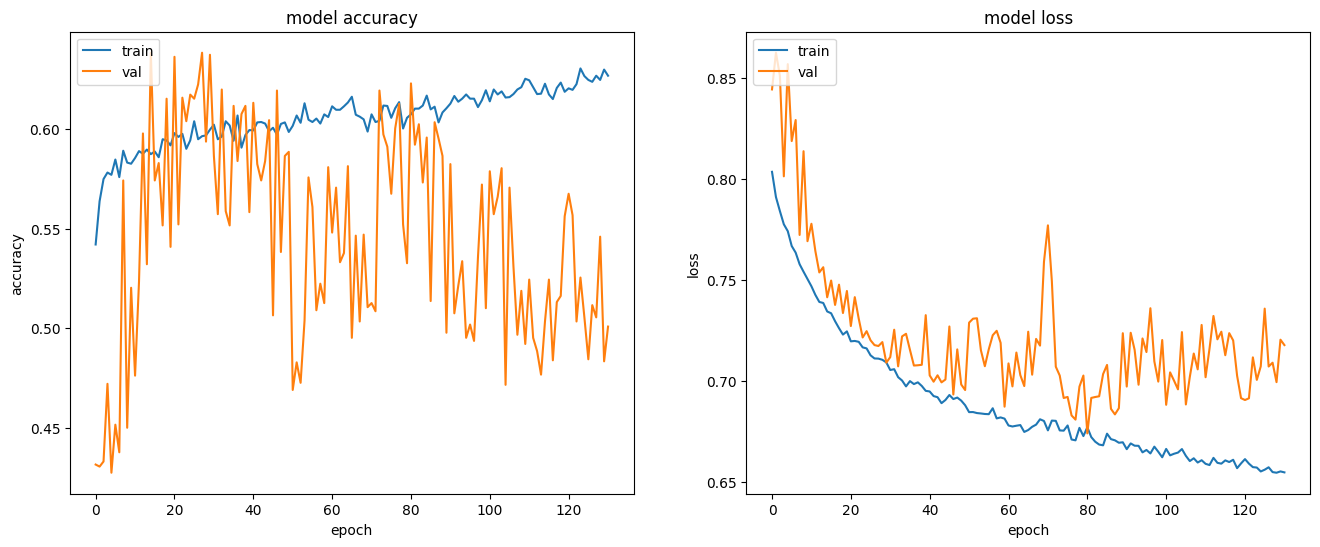

In [109]:
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(history2.history['accuracy'])
ax1.plot(history2.history['val_accuracy'])
ax1.set_title('model accuracy')
ax1.set_ylabel('accuracy')
ax1.set_xlabel('epoch')
ax1.legend(['train', 'val'], loc='upper left')

ax2.plot(history2.history['loss'])
ax2.plot(history2.history['val_loss'])
ax2.set_title('model loss')
ax2.set_ylabel('loss')
ax2.set_xlabel('epoch')
ax2.legend(['train', 'val'], loc='upper left')

In [110]:
# Predicciones de probabilidades (forma: [N, 2])
y_pred_prob = model2.predict(val_ds)

# Umbral de clasificación binaria
y_pred = (y_pred_prob > 0.5).astype(int)  # → binariza: >0.5 → 1, ≤0.5 → 0

y_true = []
for _, label_batch in val_ds:
    y_true.append(label_batch.numpy())
y_true = np.concatenate(y_true, axis=0).astype(int)  # → [N, 2]

from sklearn.metrics import classification_report, multilabel_confusion_matrix

print(classification_report(y_true, y_pred, target_names=["Healty", "symptoms"]))


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step
              precision    recall  f1-score   support

      Healty       0.59      0.41      0.49       839
    symptoms       0.64      0.78      0.70      1106

    accuracy                           0.62      1945
   macro avg       0.61      0.60      0.59      1945
weighted avg       0.62      0.62      0.61      1945



2025-08-08 23:36:52.919646: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


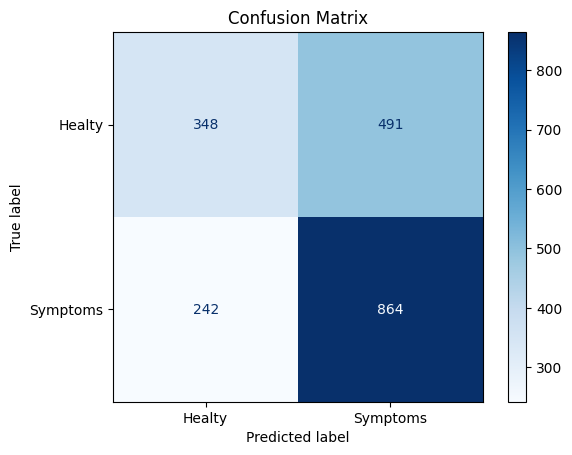

In [111]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

# 2. Define class labels (optional, but good for readability)
class_names = [f'{i}' for i in ["Healty", "Symptoms"]]

# 3. Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues) # You can choose other colormaps
plt.title('Confusion Matrix')
plt.show()


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step


/tmp/ipykernel_624269/1216267741.py:33: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(features_2d[idx, 0], features_2d[idx, 1],


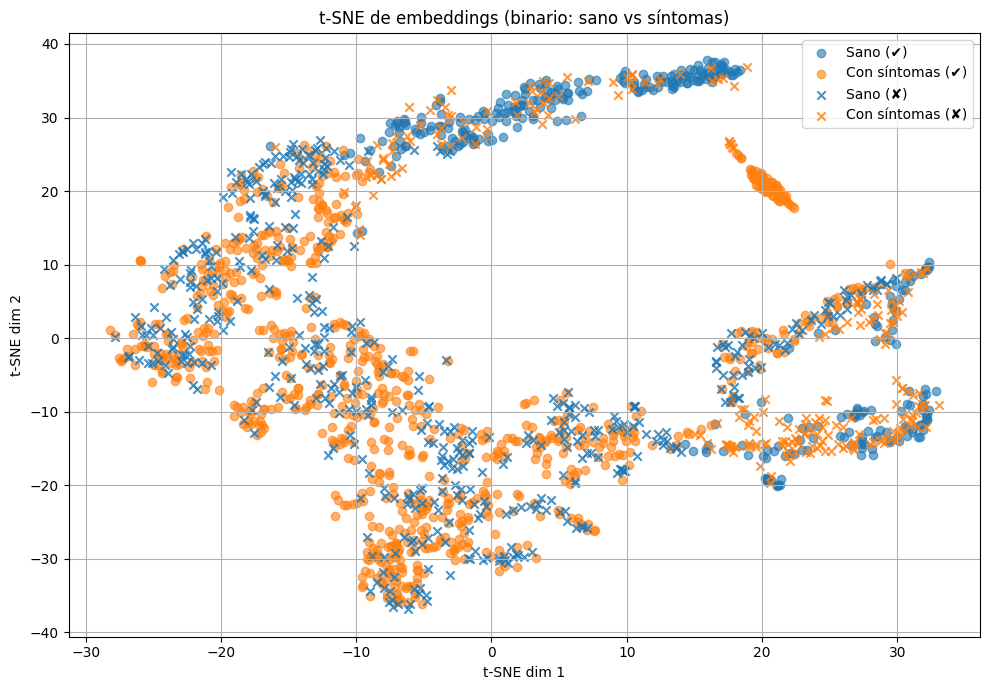

In [112]:
from sklearn.manifold import TSNE

# 1. Extraer embeddings (penúltima capa)
feature_model = tf.keras.Model(
    inputs=model2.layers[0].input,
    outputs=model2.layers[-2].output
)
features = feature_model.predict(val_ds, verbose=1)  # (N, 32)

labels_true = np.array(y_true, dtype=int).reshape(-1)  # (N,)
labels_pred = np.array(y_pred, dtype=int).reshape(-1)  # (N,)
errors = labels_true != labels_pred

# 3. t-SNE
tsne = TSNE(n_components=2, perplexity=60, random_state=42)
features_2d = tsne.fit_transform(features)

# 4. Visualización
plt.figure(figsize=(10, 7))
color_map = {0: 'tab:blue', 1: 'tab:orange'}
label_names = {0: "Sano", 1: "Con síntomas"}

# Correctos
for label in [0, 1]:
    idx = (labels_true == label) & (~errors)
    plt.scatter(features_2d[idx, 0], features_2d[idx, 1],
                label=f"{label_names[label]} (✔)",
                color=color_map[label], marker='o', alpha=0.6)

# Incorrectos
for label in [0, 1]:
    idx = (labels_true == label) & (errors)
    plt.scatter(features_2d[idx, 0], features_2d[idx, 1],
                label=f"{label_names[label]} (✘)",
                color=color_map[label], marker='x', alpha=0.8, edgecolors='k')

plt.title("t-SNE de embeddings (binario: sano vs síntomas)")
plt.xlabel("t-SNE dim 1")
plt.ylabel("t-SNE dim 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()